## Data preparation

In [1]:
%cd /home/maia-user/NeuroCBIR/
!ls

/home/maia-user/NeuroCBIR
 ADNI_preparation.ipynb      model
 cbir			     preprocessing
 CBIR.ipynb		     README.md
 CBIR_wholeBrain.ipynb	     seg_preparation.ipynb
 CBIR_wholeBrain_SVF.ipynb   subcortical_AE_training.ipynb
 compute_SVF.ipynb	    'subcortical_SVF_training .ipynb'
 data			     training
 global_AE_training.ipynb    utils
 global_SVF_training.ipynb


/usr/local/lib/python3.10/dist-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [ ]:
# import torch
# from model.autoencoder import Conv3DSparseAutoencoder
# from torchsummary import summary

# # Device setup
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Input size: [160, 176, 208]
# input_size = [64, 80, 48]

# # Initialize model and move it to the correct device
# autoencoder = Conv3DSparseAutoencoder().to(device)

# # Run summary — torchsummary will match the device of the model
# _=summary(autoencoder, (1, *input_size))

In [3]:
import sys
print(sys.executable)


/usr/bin/python3


In [4]:
import torch
import torch.nn as nn
import os
import pandas as pd
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from IPython.display import clear_output

seed = 42

(176, 208, 160) 1.0 0.0


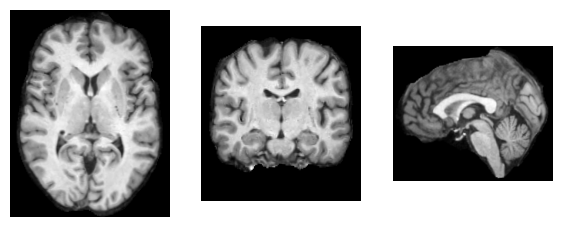

(192, 224, 160) 255 0


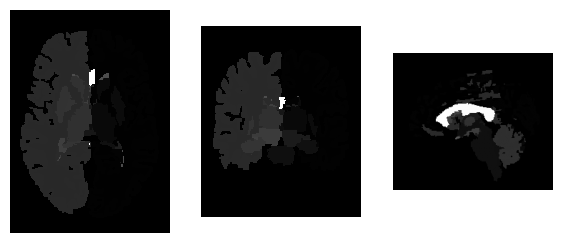

(96, 112, 80, 3) 5.027 -7.293


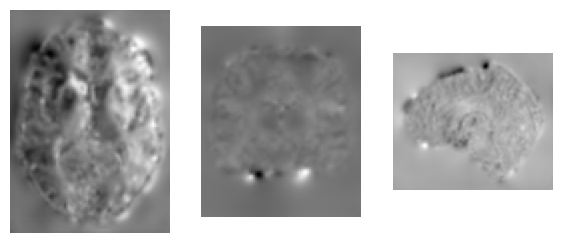

In [5]:
from preprocessing.padding import pad_mri_to_shape

# Load NIfTI file
img_seg = np.load(r"/home/maia-user/Dataset/OASIS3_NPY_UINT/OAS30001_MR_d0129.npy", allow_pickle=True).item()
mri_data = img_seg['image']
mri_data = mri_data.astype(np.float32) / 255.0
seg = img_seg['seg']

# nifti_img = nib.load(r"/home/maia-user/Dataset/OASIS3/T1w/OAS30001_MR_d2430/mri/align_norm+cropped.nii.gz")
# mri_data = nifti_img.get_fdata()

# Show a single slice (assuming 3D MRI data)
print(mri_data.shape, np.max(mri_data), np.min(mri_data))
fig, axes = plt.subplots(1, 3, figsize=(7, 3))
axes[0].imshow(mri_data[mri_data.shape[0] // 2, : ,:], cmap="gray")
axes[0].axis("off")
axes[1].imshow(mri_data[:, mri_data.shape[1] // 2, :], cmap="gray")
axes[1].axis("off")
axes[2].imshow(mri_data[:, :, mri_data.shape[2] // 2], cmap="gray")
axes[2].axis("off")
plt.show()

# Show a single slice (assuming 3D MRI data)
seg = pad_mri_to_shape(seg, target_shape=(96*2, 112*2, 80*2))
print(seg.shape, np.max(seg), np.min(seg))

fig, axes = plt.subplots(1, 3, figsize=(7, 3))
axes[0].imshow(seg[seg.shape[0] // 2, : ,:], cmap="gray")
axes[0].axis("off")
axes[1].imshow(seg[:, seg.shape[1] // 2, :], cmap="gray")
axes[1].axis("off")
axes[2].imshow(seg[:, :, seg.shape[2] // 2], cmap="gray")
axes[2].axis("off")
plt.show()

# Load SVF
svf = np.load(r"/home/maia-user/Dataset/OASIS3_NPY_SVF/FROM__OAS30001_MR_d0129__TO__OAS30001_MR_d0757.npy")

# nifti_img = nib.load(r"/home/maia-user/Dataset/OASIS3/T1w/OAS30001_MR_d2430/mri/align_norm+cropped.nii.gz")
# mri_data = nifti_img.get_fdata()

# Show a single slice (assuming 3D MRI data)
print(svf.shape, np.max(svf), np.min(svf))
fig, axes = plt.subplots(1, 3, figsize=(7, 3))
axes[0].imshow(svf[svf.shape[0] // 2, : ,:, 0], cmap="gray")
axes[0].axis("off")
axes[1].imshow(svf[:, svf.shape[1] // 2, :, 1], cmap="gray")
axes[1].axis("off")
axes[2].imshow(svf[:, :, svf.shape[2] // 2, 2], cmap="gray")
axes[2].axis("off")
plt.show()

In [6]:
from preprocessing.load_dataset import list_files_with_extension, BrainMRIDataset

# Loading MRI  paths
dataset_path = r"/home/maia-user/Dataset/OASIS3_NPY_SVF/"
file_paths, file_names = list_files_with_extension(dataset_path, extension=".npy")
raw_image_paths = np.array([os.path.join(dataset_path, file_path, file_name) for file_path, file_name in zip(file_paths, file_names)])
raw_image_ids = np.array([file_path.split('.')[0] for file_path in file_names])

# Load file with labels
labels_path = r"/home/maia-user/Dataset/OASIS3/OASIS3_UDSb4_cdr.xlsx"
labels_df = pd.read_excel(labels_path, sheet_name= 'Labels')

# Some recordings might be removed, i.e. nan labels
# Match svf and labels
raw_labels = np.array([labels_df[labels_df['OASIS_session_label'].apply(lambda x: pd.notna(x) and x in image_id)]['disease_label'].max()
                                for image_id in raw_image_ids]).astype('float32')

# Match svf and age dif
raw_ages_dif = np.array([labels_df[labels_df['OASIS_session_label'].apply(lambda x: pd.notna(x) and x in image_id)]['age_at_visit']
                                for image_id in raw_image_ids]).astype('float32')
raw_ages_dif = raw_ages_dif[:, 1] - raw_ages_dif[:, 0]

# Match svf and id
raw_ids = np.array([labels_df[labels_df['OASISID'].apply(lambda x: pd.notna(x) and x in image_id)]['OASISID'].unique()
                                for image_id in raw_image_ids])

# Filtering out undesired cases
labels = raw_labels[~np.isnan(raw_labels)]
image_paths = raw_image_paths[~np.isnan(raw_labels)]
ages_dif = raw_ages_dif[~np.isnan(raw_labels)]
ids = raw_ids[~np.isnan(raw_labels)]

print(raw_labels.shape, labels.shape)
print(labels.shape, image_paths.shape, ages_dif.shape, ids.shape)

/home/maia-user/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(2778,) (2778,)
(2778,) (2778,) (2778,) (2778, 1)


In [7]:
from preprocessing.split_dataset import stratified_patient_split

# Longitudinal splitting dataset into training and testing sets
train_set, val_set, test_set = stratified_patient_split(image_paths=image_paths, labels=labels, ages_dif=ages_dif, ids=ids)

# Print dataset sizes
print(f"Training samples: {len(train_set['image_paths'])} - IR: {np.sum(train_set['labels'])/len(train_set['image_paths']):.2f}")
print(f"Validation samples: {len(val_set['image_paths'])} - IR: {np.sum(val_set['labels'])/len(val_set['image_paths']):.2f}")
print(f"Testing samples: {len(test_set['image_paths'])} - IR: {np.sum(test_set['labels'])/len(val_set['image_paths']):.2f}")

Training samples: 1931 - IR: 0.16
Validation samples: 345 - IR: 0.17
Testing samples: 502 - IR: 0.15


In [8]:
from preprocessing.load_dataset import StratifiedBatchSampler, BrainSVFDataset
import torchio as tio

batch_size = 4  # Make sure this is even!

augmentation_transforms = tio.Compose([
                                        # tio.RandomAffine(
                                        #     scales=(0.9, 1.05),        # Random scaling
                                        #     degrees=5,               # Random rotation in degrees
                                        #     translation=5            # Random translation in mm
                                        # ),
                                        tio.RandomNoise(mean=0.0, std=0.02),
                                        # tio.RandomFlip(axes=('LR',)),  # Random left-right flip
                                    ])



# Preparing the dataset to feed the network
train_dataset = BrainSVFDataset(train_set['image_paths'], train_set['ages_dif'], train_set['labels'])
train_sampler = StratifiedBatchSampler(train_dataset, batch_size)
train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, pin_memory=True, num_workers=1)

val_dataset = BrainSVFDataset(val_set['image_paths'], val_set['ages_dif'], val_set['labels'])
val_sampler = StratifiedBatchSampler(val_dataset, batch_size)
val_loader = DataLoader(val_dataset, batch_sampler=val_sampler, num_workers=1)

test_dataset = BrainSVFDataset(test_set['image_paths'], test_set['ages_dif'], test_set['labels'])
test_sampler = StratifiedBatchSampler(test_dataset, batch_size)
test_loader = DataLoader(test_dataset, batch_sampler=test_sampler, num_workers=1)


In [9]:
dataset = BrainMRIDataset(image_paths, ages_dif, labels)

In [10]:
from model.autoencoder import Conv3DSparseAutoencoder

# Load dataset features
dataset_feats = pd.DataFrame(list(np.load("./data/dataset_feats_20250516_142452.npy", allow_pickle=True)))

In [11]:

# def group_norm(channels):
#     if channels >= 32:
#         return nn.GroupNorm(8, channels)
#     elif channels >= 16:
#         return nn.GroupNorm(4, channels)
#     else:
#         return nn.GroupNorm(2, channels)

# def conv_block(in_channels, out_channels, kernel_size=3, stride=1, padding=1, norm=True, activation=True, dropout=None):
#     layers = [nn.Conv3d(in_channels, out_channels, kernel_size, stride, padding)]
#     if norm:
#         layers.append(group_norm(out_channels))
#     if activation:
#         layers.append(nn.LeakyReLU(0.2, inplace=True))
#     if dropout is not None:
#         layers.append(nn.Dropout3d(dropout))
#     return nn.Sequential(*layers)

# def deconv_block(in_channels, out_channels, kernel_size=3, stride=2, padding=0, output_padding=0, norm=True, activation=True):
#     layers = [nn.ConvTranspose3d(in_channels, out_channels, kernel_size, stride, padding, output_padding)]
#     if norm:
#         layers.append(group_norm(out_channels))
#     if activation:
#         layers.append(nn.LeakyReLU(0.2, inplace=True))
#     return nn.Sequential(*layers)

# class Conv3DAutoencoder(nn.Module):
#     def __init__(self, input_shape=(1, 176, 208, 160), bottleneck_dim=64):
#         super().__init__()
#         self.input_shape = input_shape
#         self.bottleneck_dim = bottleneck_dim
#         input_channels = output_channels = input_shape[0]

#         # Encoder
#         self.encoder_conv = nn.Sequential(
#             conv_block(input_channels, 32, kernel_size=4, stride=2, padding=1, dropout=0.1),
#             conv_block(32, 24, kernel_size=4, stride=2, padding=1, dropout=0.1),
#             conv_block(24, 16, kernel_size=4, stride=2, padding=1),
#             conv_block(16, 8, kernel_size=4, stride=2, padding=1),
#         )

#         if bottleneck_dim is not None:
#             # Determine shape after encoder
#             with torch.no_grad():
#                 dummy = torch.zeros((1, *input_shape))
#                 conv_out = self.encoder_conv(dummy)
#                 self.conv_shape = conv_out.shape[1:]
#                 self.flat_dim = conv_out.numel() // conv_out.shape[0]

#             # Bottleneck
#             self.encoder_fc = nn.Linear(self.flat_dim, bottleneck_dim)
#             self.decoder_fc = nn.Linear(bottleneck_dim, self.flat_dim)

#         # Decoder
#         self.decoder_conv = nn.Sequential(
#             deconv_block(8, 16, kernel_size=4, padding=1, output_padding=0),
#             deconv_block(16, 24, kernel_size=4, padding=1, output_padding=0),
#             deconv_block(24, 32, kernel_size=4, padding=1, output_padding=0),
#             deconv_block(32, output_channels, kernel_size=4, padding=1, output_padding=0, norm=False, activation=False),
#         )

#     def forward(self, x):
#         x = z = self.encoder_conv(x)

#         if self.bottleneck_dim is not None:
#             x = torch.flatten(x, start_dim=1)
#             z = self.encoder_fc(x)
#             x = self.decoder_fc(z)
#             x = x.view(-1, *self.conv_shape)

#         x_out = self.decoder_conv(x)

#         return z, x_out


# # Load model
# # Config
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# bottleneck_dim=64
# autoencoder = Conv3DAutoencoder(bottleneck_dim=bottleneck_dim).to(device)
# pretrained_param = torch.load('./data/pretrained_models/CP_20250503_153007.pth')
# autoencoder.load_state_dict(pretrained_param)

In [12]:
# from utils.visualization import visualize_autoencoder_reconstruction

# sample_1 = dataset[699]
# visualize_autoencoder_reconstruction(autoencoder, sample_1, device, substructure_index=0, title_prefix="Sample 699 - ")

In [13]:
subc_str = 'svf_whole_brain'
dataset_feats.query(f"subc_str == '{subc_str}'")

,subject_id,record_id,subc_str,label,age_dif,features
0,OAS31243,FROM__OAS31243_MR_d0011__TO__OAS31243_MR_d0116,svf_whole_brain,0.0,0.287674,"[0.7481775, 0.82839864, 0.80610394, 0.82504696..."
1,OAS30574,FROM__OAS30574_MR_d0918__TO__OAS30574_MR_d1917,svf_whole_brain,0.0,2.736984,"[0.77389586, 0.8281089, 0.83800876, 0.8297442,..."
2,OAS31012,FROM__OAS31012_MR_d2449__TO__OAS31012_MR_d5114,svf_whole_brain,0.0,7.301376,"[0.77954704, 0.8366659, 0.83946294, 0.86639327..."
3,OAS30588,FROM__OAS30588_MR_d1637__TO__OAS30588_MR_d4796,svf_whole_brain,0.0,8.654793,"[0.7193567, 0.7672798, 0.69257545, 0.6034904, ..."
4,OAS31025,FROM__OAS31025_MR_d0410__TO__OAS31025_MR_d3510,svf_whole_brain,0.0,8.493149,"[0.76307285, 0.8171278, 0.78351504, 0.7654719,..."
...,...,...,...,...,...,...
2772,OAS31021,FROM__OAS31021_MR_d0049__TO__OAS31021_MR_d2281,svf_whole_brain,0.0,6.115070,"[0.7801871, 0.86189544, 0.89324427, 0.8936275,..."
2773,OAS30038,FROM__OAS30038_MR_d1214__TO__OAS30038_MR_d3376,svf_whole_brain,0.0,5.923290,"[0.7937074, 0.84524304, 0.8293842, 0.85193694,..."
2774,OAS30297,FROM__OAS30297_MR_d1712__TO__OAS30297_MR_d2331,svf_whole_brain,0.0,1.695892,"[0.77539825, 0.83862877, 0.9284497, 0.9395371,..."
2775,OAS30331,FROM__OAS30331_MR_d3478__TO__OAS30331_MR_d4694,svf_whole_brain,1.0,3.331505,"[0.80063784, 0.8625184, 0.8509919, 0.83500546,..."


In [14]:
np.stack(dataset_feats['label'].values)

array([0., 0., 0., ..., 0., 1., 0.])

## Embedding 2d representation

2025-05-16 17:41:27.509747: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-16 17:41:27.509878: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-16 17:41:36.026202: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-16 17:41:38.290678: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-16 17:41:48.701805: W tensorflow/compiler/tf2

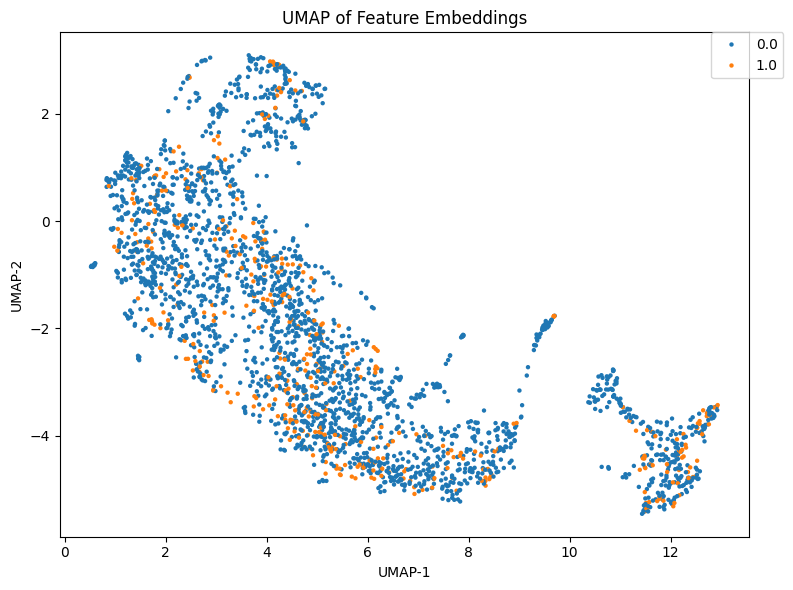

In [23]:
from cbir.projection import compute_umap_embeddings, plot_projection

# Let's say you have a feature matrix and optional labels
features = np.stack(dataset_feats['features'].values)
labels = np.stack(dataset_feats['label'].values)

embedding = compute_umap_embeddings(features)
plot_projection(embedding, labels=labels, title="UMAP of Feature Embeddings")


(array([419., 705., 564., 446., 261., 191.,  96.,  59.,  24.,  12.]),
 array([2.73895264e-03, 1.59232826e+00, 3.18191757e+00, 4.77150688e+00,
        6.36109619e+00, 7.95068550e+00, 9.54027481e+00, 1.11298641e+01,
        1.27194534e+01, 1.43090427e+01, 1.58986320e+01]),
 <BarContainer object of 10 artists>)

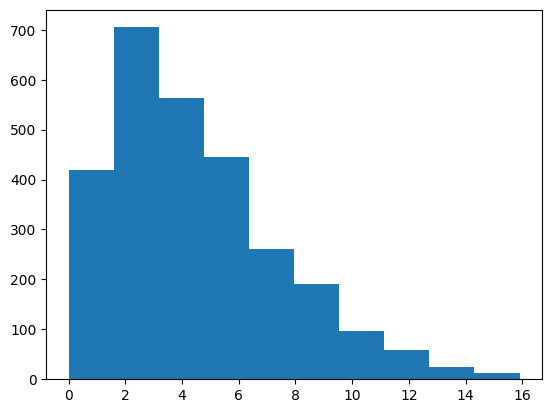

In [ ]:
labels = np.stack(dataset_feats['age_dif'].values) 
plt.hist(labels)

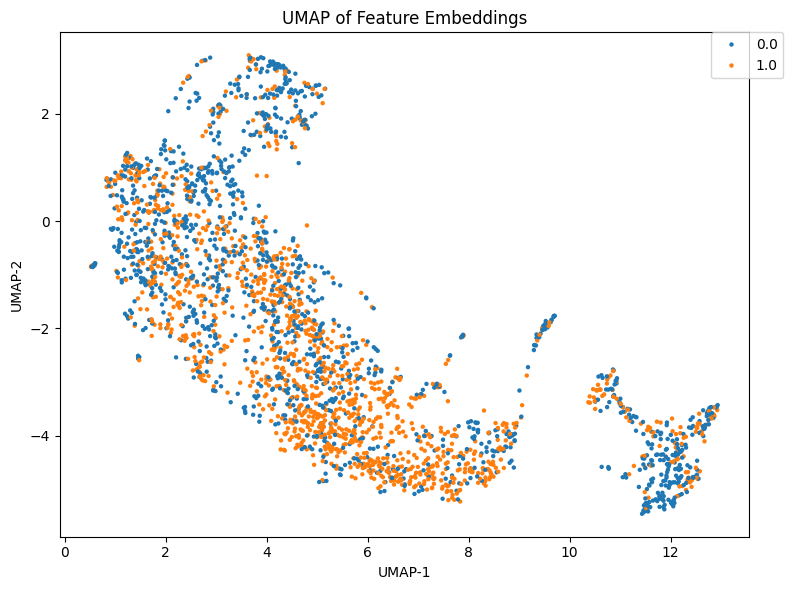

In [40]:
from cbir.projection import compute_umap_embeddings, plot_projection

# Let's say you have a feature matrix and optional labels
features = np.stack(dataset_feats['features'].values)
labels = np.stack(dataset_feats['age_dif'].values)
labels = (labels < np.median(labels)).astype(float)

plot_projection(embedding, labels=labels, title="UMAP of Feature Embeddings")


## Intra-subject evaluation

In [19]:
from cbir.feature_engineering import prepare_dataset_with_combined_features
from cbir.evaluation import evaluate_similarity_retrieval, evaluation_function_regression


In [21]:
dataset_feats

,subject_id,record_id,subc_str,label,age_dif,features
0,OAS31243,FROM__OAS31243_MR_d0011__TO__OAS31243_MR_d0116,svf_whole_brain,0.0,0.287674,"[0.7481775, 0.82839864, 0.80610394, 0.82504696..."
1,OAS30574,FROM__OAS30574_MR_d0918__TO__OAS30574_MR_d1917,svf_whole_brain,0.0,2.736984,"[0.77389586, 0.8281089, 0.83800876, 0.8297442,..."
2,OAS31012,FROM__OAS31012_MR_d2449__TO__OAS31012_MR_d5114,svf_whole_brain,0.0,7.301376,"[0.77954704, 0.8366659, 0.83946294, 0.86639327..."
3,OAS30588,FROM__OAS30588_MR_d1637__TO__OAS30588_MR_d4796,svf_whole_brain,0.0,8.654793,"[0.7193567, 0.7672798, 0.69257545, 0.6034904, ..."
4,OAS31025,FROM__OAS31025_MR_d0410__TO__OAS31025_MR_d3510,svf_whole_brain,0.0,8.493149,"[0.76307285, 0.8171278, 0.78351504, 0.7654719,..."
...,...,...,...,...,...,...
2772,OAS31021,FROM__OAS31021_MR_d0049__TO__OAS31021_MR_d2281,svf_whole_brain,0.0,6.115070,"[0.7801871, 0.86189544, 0.89324427, 0.8936275,..."
2773,OAS30038,FROM__OAS30038_MR_d1214__TO__OAS30038_MR_d3376,svf_whole_brain,0.0,5.923290,"[0.7937074, 0.84524304, 0.8293842, 0.85193694,..."
2774,OAS30297,FROM__OAS30297_MR_d1712__TO__OAS30297_MR_d2331,svf_whole_brain,0.0,1.695892,"[0.77539825, 0.83862877, 0.9284497, 0.9395371,..."
2775,OAS30331,FROM__OAS30331_MR_d3478__TO__OAS30331_MR_d4694,svf_whole_brain,1.0,3.331505,"[0.80063784, 0.8625184, 0.8509919, 0.83500546,..."


In [112]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def calculate_metrics(hits_at_k: int, hits_at_least_one: int, total_queries: int, total_retrieved: int) -> dict:
    """
    Computes precision@k and success@k.
    """
    precision_at_k = hits_at_k / total_retrieved if total_retrieved else 0
    success_at_k = hits_at_least_one / total_queries if total_queries else 0

    return {
        'precision@k': precision_at_k,
        'success@k': success_at_k,
        'num_evaluated': total_queries
    }

def evaluate_similarity_retrieval_cross(dataset_query, dataset_target, top_k=3, class_column='class_label', 
                                  evaluation_function=None, exclude_self=False, exclude_self_subject_id=False) -> dict:
    """
    Computes precision@k and success@k using cosine similarity, but evaluating retrieval based on class match instead of subject_id.
    
    Args:
        dataset (pd.DataFrame): DataFrame with 'features' and class column (e.g., 'class_label').
        top_k (int): Number of top matches to consider.
        class_column (str): Name of the column representing the class.

    Returns:
        dict: Metrics (precision@k, success@k, number of evaluated queries).
    """
    if evaluation_function is None:
        evaluation_function = evaluation_function_classification

    hits_at_k = 0
    hits_at_least_one = 0
    total_queries = 0
    total_retrieved = 0

    

    features_matrix = np.stack(dataset_target['features'].values)
    
    for i in range(len(dataset_query)):
        query = dataset_query.iloc[i]
        query_class = query[class_column]
        features = query['features'].reshape(1, -1)

        # Check if there are enough records of this class
        # class_records = dataset[dataset[class_column] == query_class]
        # if len(class_records) < top_k:
        #     continue  # Skip if not enough records of this class

        similarities = cosine_similarity(features, features_matrix)[0]
        if exclude_self:
            similarities[i] = -1  # Exclude self

        if exclude_self_subject_id:
            indexes = (dataset_target['subject_id'] == query['subject_id']).values
            similarities[indexes] = -1  # Exclude self

        top_k_indices = np.argsort(similarities)[::-1][:top_k]
        top_k_classes = dataset_target.iloc[top_k_indices][class_column].values

        # Evaluation
        hits = evaluation_function(query_class, top_k_classes)
        if hits > 0:
            hits_at_least_one += 1
        hits_at_k += hits

        total_queries += 1
        total_retrieved += top_k

    return calculate_metrics(hits_at_k, hits_at_least_one, total_queries, total_retrieved)

def evaluation_function_classification(query_class, top_k_classes):
    hits = np.sum(top_k_classes == query_class)
    return hits

def evaluation_function_regression(query_class, top_k_classes, th = 5):
    hits = np.sum((((query_class - th) <= top_k_classes) * (top_k_classes <= (query_class + th))) * 1)
    return hits

In [113]:
# Example usage
subc_strs = ['svf_whole_brain']
top_k = 5

label = 0
dataset_feats_healthy = dataset_feats.query(f"label == {label}")
combined_dataset_healthy = prepare_dataset_with_combined_features(dataset_feats_healthy, subc_strs)

label = 1
dataset_feats_dementia = dataset_feats.query(f"label == {label}")
combined_dataset_dementia = prepare_dataset_with_combined_features(dataset_feats_dementia, subc_strs)


In [ ]:
def evaluation_function_regression(query_class, top_k_classes, th = 5):
    hits = np.sum((((query_class - th) <= top_k_classes) * (top_k_classes <= (query_class + th))) * 1)
    return hits

metrics = evaluate_similarity_retrieval_cross(combined_dataset_healthy, combined_dataset_healthy, top_k, 
                                              class_column="age_dif", evaluation_function=evaluation_function_regression,
                                              exclude_self=True, exclude_self_subject_id=True)

print(f"Precision@{top_k}: {metrics['precision@k']:.4f}")
print(f"Success@{top_k}: {metrics['success@k']:.4f}")

Precision@5: 0.8745
Success@5: 0.9860


In [ ]:
def evaluation_function_regression(query_class, top_k_classes, th = 5):
    hits = np.sum((((query_class - th) <= top_k_classes) * (top_k_classes <= (query_class + th))) * 1)
    return hits

metrics = evaluate_similarity_retrieval_cross(combined_dataset_healthy, combined_dataset_healthy, top_k, 
                                              class_column="age_dif", evaluation_function=evaluation_function_regression,
                                              exclude_self=True, exclude_self_subject_id=False)

print(f"Precision@{top_k}: {metrics['precision@k']:.4f}")
print(f"Success@{top_k}: {metrics['success@k']:.4f}")

Precision@5: 0.8823
Success@5: 0.9970


In [ ]:
def evaluation_function_regression(query_class, top_k_classes, th = 5):
    hits = np.sum((((query_class - th) <= top_k_classes) * (top_k_classes <= (query_class + th))) * 1)
    return hits

metrics = evaluate_similarity_retrieval_cross(combined_dataset_dementia, combined_dataset_healthy, top_k, 
                                              class_column="age_dif", evaluation_function=evaluation_function_regression,
                                              exclude_self=False, exclude_self_subject_id=True)

print(f"Precision@{top_k}: {metrics['precision@k']:.4f}")
print(f"Success@{top_k}: {metrics['success@k']:.4f}")

Precision@5: 0.6965
Success@5: 0.9600


In [ ]:
def evaluation_function_regression(query_class, top_k_classes, th = 5):
    hits = np.sum((((query_class - th) <= top_k_classes) * (top_k_classes <= (query_class + th))) * 1)
    return hits

metrics = evaluate_similarity_retrieval_cross(combined_dataset_dementia, combined_dataset_dementia, top_k, 
                                              class_column="age_dif", evaluation_function=evaluation_function_regression,
                                              exclude_self=True, exclude_self_subject_id=True)

print(f"Precision@{top_k}: {metrics['precision@k']:.4f}")
print(f"Success@{top_k}: {metrics['success@k']:.4f}")

Precision@5: 0.8913
Success@5: 0.9859


In [117]:
def evaluation_function_regression(query_class, top_k_classes, th = 10):
    hits = np.sum((((query_class - th) <= top_k_classes) * (top_k_classes <= (query_class + th))) * 1)
    return hits

metrics = evaluate_similarity_retrieval_cross(combined_dataset_dementia, combined_dataset_healthy, top_k, 
                                              class_column="age_dif", evaluation_function=evaluation_function_regression,
                                              exclude_self=False, exclude_self_subject_id=True)

print(f"Precision@{top_k}: {metrics['precision@k']:.4f}")
print(f"Success@{top_k}: {metrics['success@k']:.4f}")

Precision@5: 0.9948
Success@5: 1.0000


In [129]:
from tabulate import tabulate
from tqdm import tqdm
import pandas as pd

results = []
list_subc_strs = [
    ['svf_whole_brain'],
]

def evaluation_function_regression(query_class, top_k_classes, th = 1):
    hits = np.sum((((query_class - th) <= top_k_classes) * (top_k_classes <= (query_class + th))) * 1)
    return hits


list_top_k = [1, 3, 5]

# Estimate total iterations
total_iterations = len(list_subc_strs) * len(list_top_k)

with tqdm(total=total_iterations, desc="Evaluating combinations") as pbar:
    for subc_strs in list_subc_strs:
        for top_k in list_top_k:
            combined_dataset = prepare_dataset_with_combined_features(dataset_feats, subc_strs)
            metrics = evaluate_similarity_retrieval_cross(combined_dataset_healthy, combined_dataset_healthy, top_k, 
                                              class_column="age_dif", evaluation_function=evaluation_function_regression,
                                              exclude_self=True, exclude_self_subject_id=True)

            results.append({
                "Structures": ', '.join(subc_strs),
                "Top-K": top_k,
                "Precision@K": round(metrics['precision@k'], 4),
                "Success@K": round(metrics['success@k'], 4),
                "Evaluated Records": metrics['num_evaluated'],
            })

            pbar.update(1)  # Increment progress

# Pretty print results
print(tabulate(results, headers="keys", tablefmt="fancy_grid"))
    

Evaluating combinations: 100%|██████████| 3/3 [08:34<00:00, 171.57s/it]

╒═════════════════╤═════════╤═══════════════╤═════════════╤═════════════════════╕
│ Structures      │   Top-K │   Precision@K │   Success@K │   Evaluated Records │
╞═════════════════╪═════════╪═══════════════╪═════════════╪═════════════════════╡
│ svf_whole_brain │       1 │        0.3027 │      0.3027 │                2352 │
├─────────────────┼─────────┼───────────────┼─────────────┼─────────────────────┤
│ svf_whole_brain │       3 │        0.2999 │      0.6071 │                2352 │
├─────────────────┼─────────┼───────────────┼─────────────┼─────────────────────┤
│ svf_whole_brain │       5 │        0.2989 │      0.75   │                2352 │
╘═════════════════╧═════════╧═══════════════╧═════════════╧═════════════════════╛


In [127]:
from tabulate import tabulate
from tqdm import tqdm
import pandas as pd

results = []
list_subc_strs = [
    ['svf_whole_brain'],
]

def evaluation_function_regression(query_class, top_k_classes, th = 3):
    hits = np.sum((((query_class - th) <= top_k_classes) * (top_k_classes <= (query_class + th))) * 1)
    return hits


list_top_k = [1, 3, 5]

# Estimate total iterations
total_iterations = len(list_subc_strs) * len(list_top_k)

with tqdm(total=total_iterations, desc="Evaluating combinations") as pbar:
    for subc_strs in list_subc_strs:
        for top_k in list_top_k:
            combined_dataset = prepare_dataset_with_combined_features(dataset_feats, subc_strs)
            metrics = evaluate_similarity_retrieval_cross(combined_dataset_dementia, combined_dataset_dementia, top_k, 
                                              class_column="age_dif", evaluation_function=evaluation_function_regression,
                                              exclude_self=True, exclude_self_subject_id=True)

            results.append({
                "Structures": ', '.join(subc_strs),
                "Top-K": top_k,
                "Precision@K": round(metrics['precision@k'], 4),
                "Success@K": round(metrics['success@k'], 4),
                "Evaluated Records": metrics['num_evaluated'],
            })

            pbar.update(1)  # Increment progress

# Pretty print results
print(tabulate(results, headers="keys", tablefmt="fancy_grid"))
    

Evaluating combinations: 100%|██████████| 3/3 [00:28<00:00,  9.49s/it]

╒═════════════════╤═════════╤═══════════════╤═════════════╤═════════════════════╕
│ Structures      │   Top-K │   Precision@K │   Success@K │   Evaluated Records │
╞═════════════════╪═════════╪═══════════════╪═════════════╪═════════════════════╡
│ svf_whole_brain │       1 │        0.7082 │      0.7082 │                 425 │
├─────────────────┼─────────┼───────────────┼─────────────┼─────────────────────┤
│ svf_whole_brain │       3 │        0.6871 │      0.9035 │                 425 │
├─────────────────┼─────────┼───────────────┼─────────────┼─────────────────────┤
│ svf_whole_brain │       5 │        0.6885 │      0.9435 │                 425 │
╘═════════════════╧═════════╧═══════════════╧═════════════╧═════════════════════╛


In [126]:
from tabulate import tabulate
from tqdm import tqdm
import pandas as pd

results = []
list_subc_strs = [
    ['svf_whole_brain'],
]

def evaluation_function_regression(query_class, top_k_classes, th = 1):
    hits = np.sum((((query_class - th) <= top_k_classes) * (top_k_classes <= (query_class + th))) * 1)
    return hits


list_top_k = [1, 3, 5]

# Estimate total iterations
total_iterations = len(list_subc_strs) * len(list_top_k)

with tqdm(total=total_iterations, desc="Evaluating combinations") as pbar:
    for subc_strs in list_subc_strs:
        for top_k in list_top_k:
            combined_dataset = prepare_dataset_with_combined_features(dataset_feats, subc_strs)
            metrics = evaluate_similarity_retrieval_cross(combined_dataset_dementia, combined_dataset_healthy, top_k, 
                                              class_column="age_dif", evaluation_function=evaluation_function_regression,
                                              exclude_self=False, exclude_self_subject_id=True)

            results.append({
                "Structures": ', '.join(subc_strs),
                "Top-K": top_k,
                "Precision@K": round(metrics['precision@k'], 4),
                "Success@K": round(metrics['success@k'], 4),
                "Evaluated Records": metrics['num_evaluated'],
            })

            pbar.update(1)  # Increment progress

# Pretty print results
print(tabulate(results, headers="keys", tablefmt="fancy_grid"))

Evaluating combinations: 100%|██████████| 3/3 [01:32<00:00, 30.96s/it]

╒═════════════════╤═════════╤═══════════════╤═════════════╤═════════════════════╕
│ Structures      │   Top-K │   Precision@K │   Success@K │   Evaluated Records │
╞═════════════════╪═════════╪═══════════════╪═════════════╪═════════════════════╡
│ svf_whole_brain │       1 │        0.3224 │      0.3224 │                 425 │
├─────────────────┼─────────┼───────────────┼─────────────┼─────────────────────┤
│ svf_whole_brain │       3 │        0.3059 │      0.6188 │                 425 │
├─────────────────┼─────────┼───────────────┼─────────────┼─────────────────────┤
│ svf_whole_brain │       5 │        0.3068 │      0.7647 │                 425 │
╘═════════════════╧═════════╧═══════════════╧═════════════╧═════════════════════╛


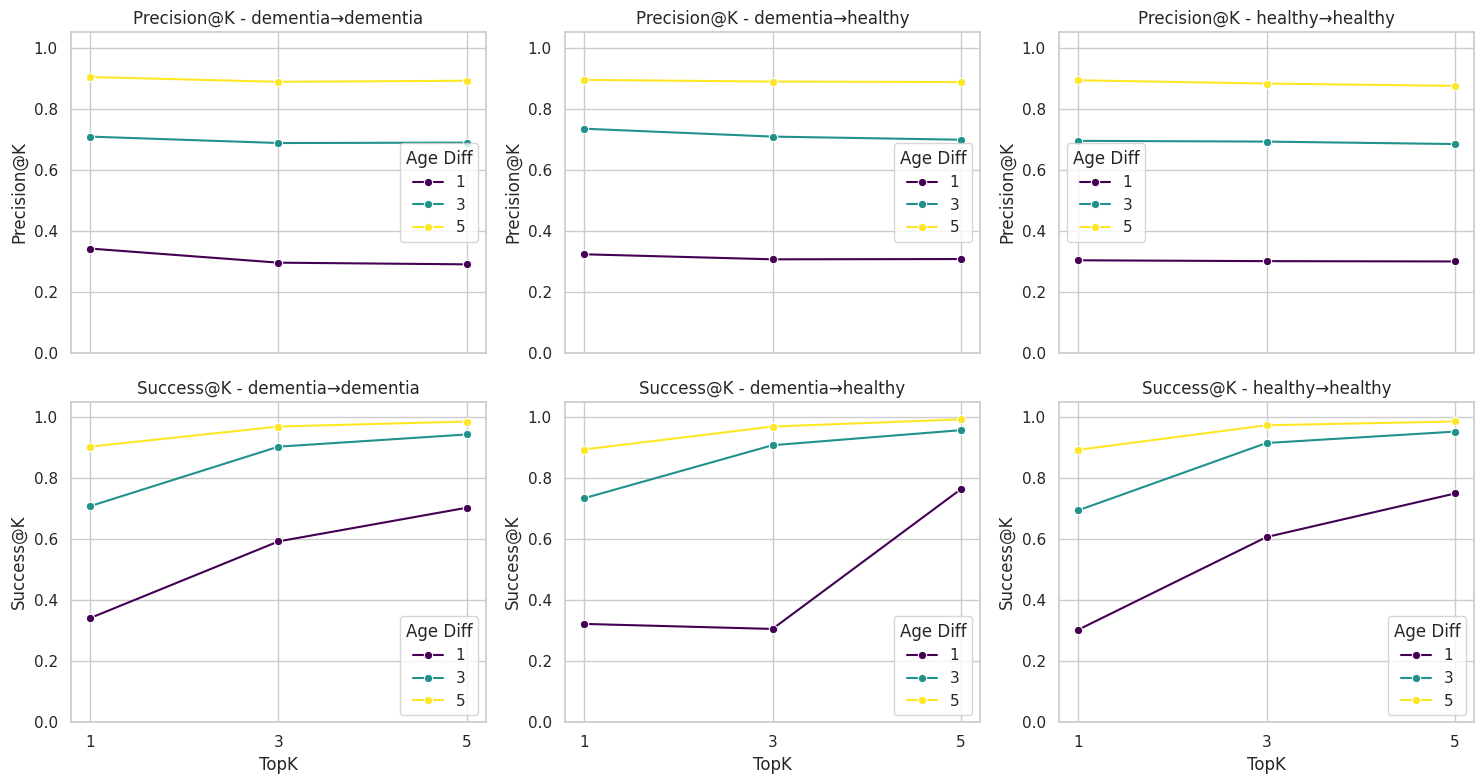

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the data
data = [
    # query healthy -> dataset healthy
    ("healthy→healthy", 1, 1, 0.3027, 0.3027),
    ("healthy→healthy", 1, 3, 0.2999, 0.6071),
    ("healthy→healthy", 1, 5, 0.2989, 0.75),
    ("healthy→healthy", 3, 1, 0.6943, 0.6943),
    ("healthy→healthy", 3, 3, 0.6918, 0.9154),
    ("healthy→healthy", 3, 5, 0.6838, 0.9528),
    ("healthy→healthy", 5, 1, 0.8929, 0.8929),
    ("healthy→healthy", 5, 3, 0.8821, 0.9736),
    ("healthy→healthy", 5, 5, 0.8745, 0.986),

    # dementia query to healthy dataset
    ("dementia→healthy", 1, 1, 0.3224, 0.3224),
    ("dementia→healthy", 1, 3, 0.3059, 0.3059),
    ("dementia→healthy", 1, 5, 0.3068, 0.7647),
    ("dementia→healthy", 3, 1, 0.7341, 0.7341),
    ("dementia→healthy", 3, 3, 0.7082, 0.9082),
    ("dementia→healthy", 3, 5, 0.6979, 0.9576),
    ("dementia→healthy", 5, 1, 0.8941, 0.8941),
    ("dementia→healthy", 5, 3, 0.8886, 0.9694),
    ("dementia→healthy", 5, 5, 0.8871, 0.9929),

    # dementia query to dementia dataset
    ("dementia→dementia", 1, 1, 0.3412, 0.3412),
    ("dementia→dementia", 1, 3, 0.2949, 0.5929),
    ("dementia→dementia", 1, 5, 0.2894, 0.7035),
    ("dementia→dementia", 3, 1, 0.7082, 0.7082),
    ("dementia→dementia", 3, 3, 0.6871, 0.9035),
    ("dementia→dementia", 3, 5, 0.6885, 0.9435),
    ("dementia→dementia", 5, 1, 0.9035, 0.9035),
    ("dementia→dementia", 5, 3, 0.8878, 0.9694),
    ("dementia→dementia", 5, 5, 0.8913, 0.9859),
]

# Convert to DataFrame
df = pd.DataFrame(data, columns=["Query→Dataset", "AgeDiff", "TopK", "Precision@K", "Success@K"])

# Set style
sns.set(style="whitegrid")

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=False)
axes = axes.flatten()

# Plot
for i, metric in enumerate(["Precision@K", "Success@K"]):
    for j, (query_dataset, sub_df) in enumerate(df.groupby("Query→Dataset")):
        ax = axes[i * 3 + j]
        sns.lineplot(
            data=sub_df,
            x="TopK",
            y=metric,
            hue="AgeDiff",
            marker="o",
            palette="viridis",
            ax=ax
        )
        ax.set_title(f"{metric} - {query_dataset}")
        ax.set_xticks([1,3,5])
        ax.set_ylim(0, 1.05)
        ax.legend(title="Age Diff")
        ax.grid(True)

plt.tight_layout()
plt.show()
